Using device: cuda


C:\Users\asojitra\AppData\Local\Temp\ipykernel_33404\903968270.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma_cmap = mpl.cm.get_cmap('plasma')


u_all shape: (10000, 128, 1)
s_all raw shape: (10000, 128, 224)
s_all final shape [N, T, X]: (10000, 224, 128)


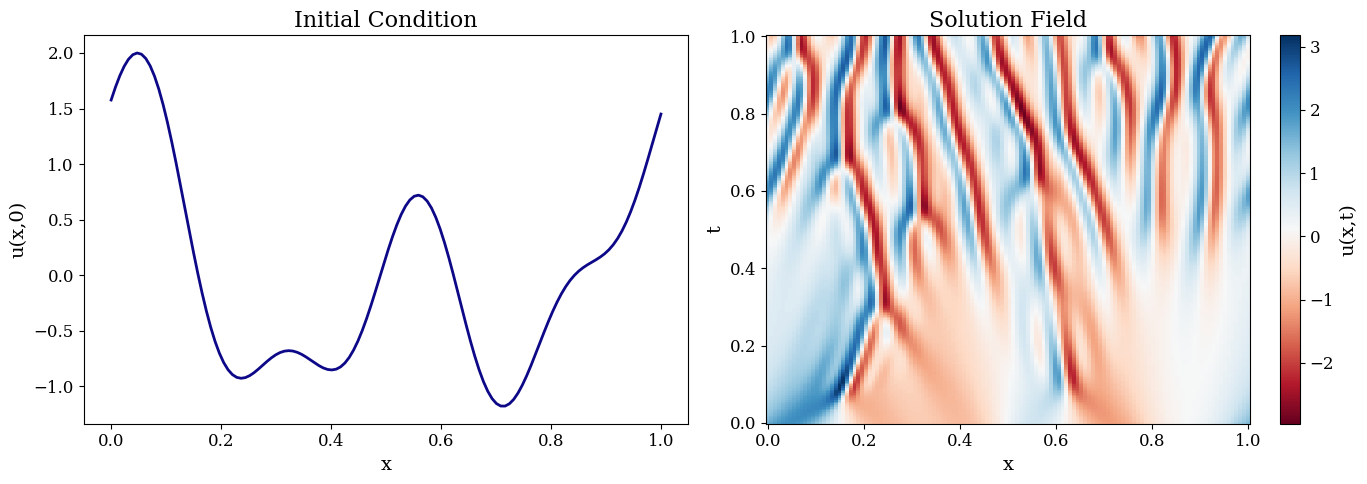

Train full: (8000, 128, 1) (8000, 224, 128)
Test      : (2000, 128, 1) (2000, 224, 128)
Using train sizes: [100, 250, 500, 1000, 2000, 4000, 7000]

TRAINING WITH n_train = 100

[FEDONet] Training with 100 samples
[FEDO | n=100] Epoch [   1/6000] | Train Loss: 1.090786e+00 | Test Loss: 1.098443e+00 | LR: 9.998e-04
[FEDO | n=100] Epoch [ 100/6000] | Train Loss: 6.306320e-01 | Test Loss: 6.686853e-01 | LR: 9.791e-04
[FEDO | n=100] Epoch [ 200/6000] | Train Loss: 4.662876e-01 | Test Loss: 5.293368e-01 | LR: 9.587e-04
[FEDO | n=100] Epoch [ 300/6000] | Train Loss: 3.651651e-01 | Test Loss: 4.375403e-01 | LR: 9.387e-04
[FEDO | n=100] Epoch [ 400/6000] | Train Loss: 2.933114e-01 | Test Loss: 3.619421e-01 | LR: 9.192e-04
[FEDO | n=100] Epoch [ 500/6000] | Train Loss: 2.574211e-01 | Test Loss: 3.253737e-01 | LR: 9.000e-04
[FEDO | n=100] Epoch [ 600/6000] | Train Loss: 2.448462e-01 | Test Loss: 3.147293e-01 | LR: 8.812e-04
[FEDO | n=100] Epoch [ 700/6000] | Train Loss: 2.127391e-01 | Test Loss: 

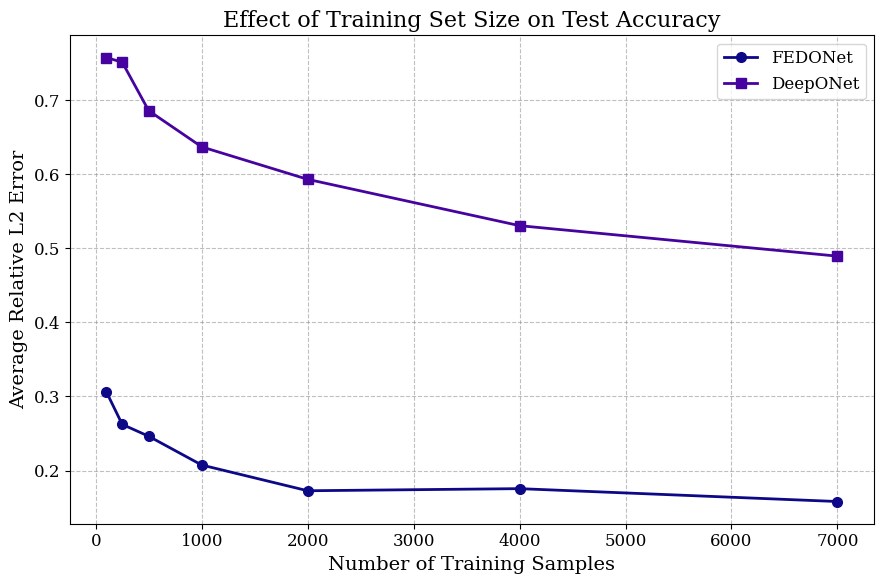

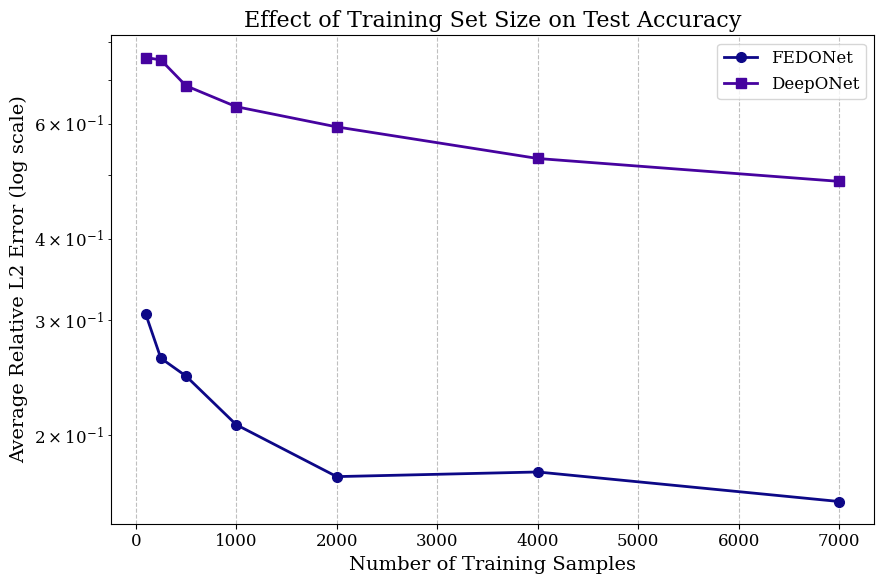

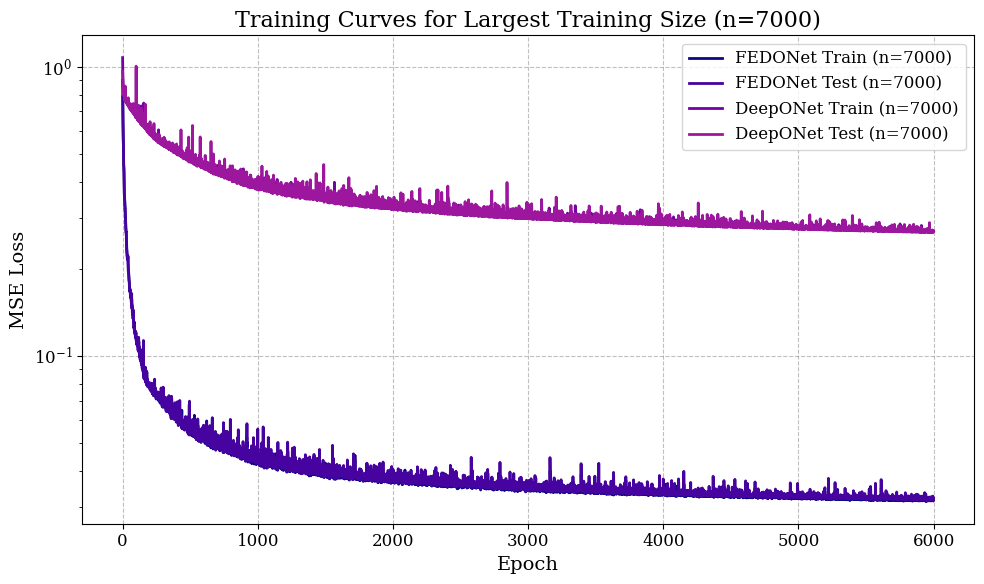

In [3]:
# ============================================================
# EFFECT OF TRAINING SET SIZE ON TEST AVG RELATIVE L2 ERROR
# FEDONet vs Vanilla DeepONet
# Full end-to-end fresh script
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2. USER CONFIG
# ============================================================
data_path = "Kuramoto_Sivashinsky_dataset_sine_initialization_4_random_terms.npz"

batch_size = 256
learning_rate = 1e-3
num_epochs = 6000          # increase later if needed
weight_decay = 0.0

# choose training sizes that are <= full training set size
train_sizes = [100, 250, 500, 1000, 2000, 4000, 7000, 9999]

# Fourier feature size for FEDONet trunk
fourier_mapping_size = 256

# plotting / verbosity
print_every = 100

# ============================================================
# 3. PLOTTING STYLE
# ============================================================
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300

    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12

    mpl.rcParams['lines.linewidth'] = 2
    mpl.rcParams['lines.markersize'] = 7

    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    mpl.rcParams['image.cmap'] = 'plasma'

    plasma_cmap = mpl.cm.get_cmap('plasma')
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, 10)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

set_plot_params()

# ============================================================
# 4. ERROR METRICS
# ============================================================
def relative_l2_error_samplewise(y_true, y_pred):
    """
    y_true, y_pred: numpy arrays of shape [N, T, X]
    returns: numpy array of shape [N]
    """
    n = y_true.shape[0]
    errors = np.zeros(n)
    for i in range(n):
        num = np.linalg.norm(y_true[i] - y_pred[i])
        den = np.linalg.norm(y_true[i]) + 1e-12
        errors[i] = num / den
    return errors

def average_relative_l2_error(y_true, y_pred):
    return relative_l2_error_samplewise(y_true, y_pred).mean()

# ============================================================
# 5. LOAD DATA
# ============================================================
data = np.load(data_path)
u_all = data['u_train']                  # expected shape: [N, 128]
s_all = data['s_train'][:, :, 0:224]     # expected shape: [N, 128, 224] or similar

print("u_all shape:", u_all.shape)
print("s_all raw shape:", s_all.shape)

# Your original code used s_train[sample_idx].T in plotting, so we keep
# the learning target as shape [N, T, X] for the network output
# If s_all is [N, X, T], transpose it to [N, T, X].
if s_all.shape[1] == 128 and s_all.shape[2] == 224:
    s_all = np.transpose(s_all, (0, 2, 1))   # [N, 224, 128]
elif s_all.shape[1] == 224 and s_all.shape[2] == 128:
    pass
else:
    raise ValueError(f"Unexpected s_all shape: {s_all.shape}")

print("s_all final shape [N, T, X]:", s_all.shape)

# ============================================================
# 6. VISUALIZE ONE SAMPLE
# ============================================================
sample_idx = random.randint(0, u_all.shape[0] - 1)

x = np.linspace(0, 1, 128)
t = np.linspace(0, 1, 224)
XX, TT = np.meshgrid(x, t)

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121)
ax1.plot(x, u_all[sample_idx])
ax1.set_xlabel('x')
ax1.set_ylabel('u(x,0)')
ax1.set_title('Initial Condition')

ax2 = fig.add_subplot(122)
pcm = ax2.pcolor(XX, TT, s_all[sample_idx], cmap='RdBu')
ax2.set_xlabel('x')
ax2.set_ylabel('t')
ax2.set_title('Solution Field')
fig.colorbar(pcm, ax=ax2, label='u(x,t)')
plt.tight_layout()
plt.show()

# ============================================================
# 7. TRAIN/TEST SPLIT
# ============================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    u_all, s_all, test_size=0.2, random_state=42
)

print("Train full:", X_train_full.shape, y_train_full.shape)
print("Test      :", X_test.shape, y_test.shape)

# Clip train_sizes to available train size
max_train_size = X_train_full.shape[0]
train_sizes = [n for n in train_sizes if n <= max_train_size]
print("Using train sizes:", train_sizes)

# ============================================================
# 8. DATASET
# ============================================================
class KSOperatorDataset(Dataset):
    def __init__(self, initial_condition, full_solution):
        """
        initial_condition: [N, 128]
        full_solution    : [N, 224, 128]
        """
        self.initial_condition = torch.tensor(initial_condition, dtype=torch.float32)
        self.full_solution = torch.tensor(full_solution, dtype=torch.float32)

        self.grid_size_x = 128
        self.grid_size_t = 224

        grid_x = np.linspace(0, 1, self.grid_size_x)
        grid_t = np.linspace(0, 1, self.grid_size_t)

        # indexing='xy' gives X,T shaped [T,X] if fed meshgrid(t, x) differently;
        # here keep explicit shape [T, X, 2]
        Xg, Tg = np.meshgrid(grid_x, grid_t)
        coords = np.stack([Xg, Tg], axis=-1)   # [T, X, 2]
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.initial_condition.shape[0]

    def __getitem__(self, idx):
        return self.initial_condition[idx], self.full_solution[idx]

# ============================================================
# 9. MODELS
# ============================================================
class FourierEmbedding(nn.Module):
    def __init__(self, input_dim, mapping_size=256, scale=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        # x: [N, input_dim]
        x_proj = 2 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class TrunkNetFEDO(nn.Module):
    def __init__(self, input_dim=2, mapping_size=256, trunk_width=128, output_dim=128):
        super().__init__()
        self.fourier_embed = FourierEmbedding(input_dim, mapping_size=mapping_size)
        in_dim = 2 * mapping_size
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, trunk_width),
            nn.ReLU(),
            nn.Linear(trunk_width, trunk_width),
            nn.ReLU(),
            nn.Linear(trunk_width, output_dim),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.net(x)

class BranchNetFEDO(nn.Module):
    def __init__(self, input_dim=128, output_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.net(x)

class FEDONet(nn.Module):
    def __init__(self, branch_dim=128, trunk_output_dim=128, mapping_size=256):
        super().__init__()
        self.branch_net = BranchNetFEDO(input_dim=branch_dim, output_dim=trunk_output_dim)
        self.trunk_net = TrunkNetFEDO(input_dim=2, mapping_size=mapping_size, output_dim=trunk_output_dim)

    def forward(self, initial_condition, coords):
        """
        initial_condition: [B, 128]
        coords: [T, X, 2]
        output: [B, T, X]
        """
        B = initial_condition.size(0)
        T = coords.size(0)
        X = coords.size(1)

        coords_flat = coords.view(-1, 2)                 # [T*X, 2]
        trunk_out = self.trunk_net(coords_flat)          # [T*X, p]
        branch_out = self.branch_net(initial_condition)  # [B, p]

        out = torch.matmul(branch_out, trunk_out.T)      # [B, T*X]
        out = out.view(B, T, X)
        return out

class TrunkNetDeepONet(nn.Module):
    def __init__(self, input_dim=2, output_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.net(x)

class BranchNetDeepONet(nn.Module):
    def __init__(self, input_dim=128, output_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_dim=128, trunk_output_dim=128):
        super().__init__()
        self.branch_net = BranchNetDeepONet(input_dim=branch_dim, output_dim=trunk_output_dim)
        self.trunk_net = TrunkNetDeepONet(input_dim=2, output_dim=trunk_output_dim)

    def forward(self, initial_condition, coords):
        """
        initial_condition: [B, 128]
        coords: [T, X, 2]
        output: [B, T, X]
        """
        B = initial_condition.size(0)
        T = coords.size(0)
        X = coords.size(1)

        coords_flat = coords.view(-1, 2)                 # [T*X, 2]
        trunk_out = self.trunk_net(coords_flat)          # [T*X, p]
        branch_out = self.branch_net(initial_condition)  # [B, p]

        out = torch.matmul(branch_out, trunk_out.T)      # [B, T*X]
        out = out.view(B, T, X)
        return out

# ============================================================
# 10. TRAIN / EVAL HELPERS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, coords, device):
    model.train()
    running_loss = 0.0

    for ic, sol in loader:
        ic = ic.to(device)
        sol = sol.to(device)

        optimizer.zero_grad()
        pred = model(ic, coords)
        loss = criterion(pred, sol)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * ic.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, coords, device):
    model.eval()
    running_loss = 0.0

    for ic, sol in loader:
        ic = ic.to(device)
        sol = sol.to(device)

        pred = model(ic, coords)
        loss = criterion(pred, sol)
        running_loss += loss.item() * ic.size(0)

    return running_loss / len(loader.dataset)

@torch.no_grad()
def predict_dataset(model, loader, coords, device):
    model.eval()
    preds = []
    trues = []

    for ic, sol in loader:
        ic = ic.to(device)
        pred = model(ic, coords).cpu().numpy()
        preds.append(pred)
        trues.append(sol.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    return trues, preds

def train_model(
    model,
    train_loader,
    test_loader,
    coords,
    device,
    num_epochs=1500,
    learning_rate=1e-3,
    weight_decay=0.0,
    print_prefix=""
):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda e: 0.9 ** (e / 500))

    train_losses = []
    test_losses = []

    best_state = None
    best_test_loss = np.inf

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, coords, device)
        test_loss = eval_loss(model, test_loader, criterion, coords, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()

        if (epoch + 1) % print_every == 0 or epoch == 0 or epoch == num_epochs - 1:
            print(f"{print_prefix} Epoch [{epoch+1:4d}/{num_epochs}] | "
                  f"Train Loss: {train_loss:.6e} | Test Loss: {test_loss:.6e} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.3e}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, test_losses

# ============================================================
# 11. PREPARE FIXED TEST SET
# ============================================================
test_dataset = KSOperatorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

coords = test_dataset.coords.to(device)

# ============================================================
# 12. EXPERIMENT LOOP OVER TRAINING SIZES
# ============================================================
results = []

all_train_curves_fedo = {}
all_test_curves_fedo = {}
all_train_curves_deep = {}
all_test_curves_deep = {}

for n_train in train_sizes:
    print("\n" + "=" * 80)
    print(f"TRAINING WITH n_train = {n_train}")
    print("=" * 80)

    # deterministic subset of the full training pool
    X_sub = X_train_full[:n_train]
    y_sub = y_train_full[:n_train]

    train_dataset = KSOperatorDataset(X_sub, y_sub)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # ---------------- FEDONet ----------------
    print(f"\n[FEDONet] Training with {n_train} samples")
    fedonet = FEDONet(branch_dim=128, trunk_output_dim=128, mapping_size=fourier_mapping_size).to(device)

    fedonet, fedo_train_losses, fedo_test_losses = train_model(
        fedonet,
        train_loader,
        test_loader,
        coords,
        device,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        print_prefix=f"[FEDO | n={n_train}]"
    )

    y_true_fedo, y_pred_fedo = predict_dataset(fedonet, test_loader, coords, device)
    avg_rel_l2_fedo = average_relative_l2_error(y_true_fedo, y_pred_fedo)

    # ---------------- DeepONet ----------------
    print(f"\n[DeepONet] Training with {n_train} samples")
    deeponet = DeepONet(branch_dim=128, trunk_output_dim=128).to(device)

    deeponet, deep_train_losses, deep_test_losses = train_model(
        deeponet,
        train_loader,
        test_loader,
        coords,
        device,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        print_prefix=f"[DEEP | n={n_train}]"
    )

    y_true_deep, y_pred_deep = predict_dataset(deeponet, test_loader, coords, device)
    avg_rel_l2_deep = average_relative_l2_error(y_true_deep, y_pred_deep)

    results.append({
        "n_train": n_train,
        "fedonet_avg_rel_l2": avg_rel_l2_fedo,
        "deeponet_avg_rel_l2": avg_rel_l2_deep
    })

    all_train_curves_fedo[n_train] = fedo_train_losses
    all_test_curves_fedo[n_train] = fedo_test_losses
    all_train_curves_deep[n_train] = deep_train_losses
    all_test_curves_deep[n_train] = deep_test_losses

    print(f"\nRESULT for n_train={n_train}")
    print(f"FEDONet  Avg Rel L2 Error : {avg_rel_l2_fedo:.6e}")
    print(f"DeepONet Avg Rel L2 Error : {avg_rel_l2_deep:.6e}")

# ============================================================
# 13. SUMMARY TABLE
# ============================================================
table_data = []
for row in results:
    table_data.append([
        row["n_train"],
        f"{row['fedonet_avg_rel_l2']:.6e}",
        f"{row['deeponet_avg_rel_l2']:.6e}"
    ])

print("\n" + "=" * 80)
print("FINAL SUMMARY: AVERAGE TEST RELATIVE L2 ERROR")
print("=" * 80)
print(tabulate(
    table_data,
    headers=["# Training Samples", "FEDONet Avg Rel L2", "DeepONet Avg Rel L2"],
    tablefmt="grid"
))

# ============================================================
# 14. PLOT: AVG REL L2 ERROR VS TRAINING SIZE
# ============================================================
n_vals = [r["n_train"] for r in results]
fedo_vals = [r["fedonet_avg_rel_l2"] for r in results]
deep_vals = [r["deeponet_avg_rel_l2"] for r in results]

plt.figure(figsize=(9, 6))
plt.plot(n_vals, fedo_vals, marker='o', label='FEDONet')
plt.plot(n_vals, deep_vals, marker='s', label='DeepONet')
plt.xlabel('Number of Training Samples')
plt.ylabel('Average Relative L2 Error')
plt.title('Effect of Training Set Size on Test Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 15. OPTIONAL: SEMILOG PLOT
# ============================================================
plt.figure(figsize=(9, 6))
plt.semilogy(n_vals, fedo_vals, marker='o', label='FEDONet')
plt.semilogy(n_vals, deep_vals, marker='s', label='DeepONet')
plt.xlabel('Number of Training Samples')
plt.ylabel('Average Relative L2 Error (log scale)')
plt.title('Effect of Training Set Size on Test Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 16. OPTIONAL: SHOW FINAL TRAINING CURVES FOR LARGEST SIZE
# ============================================================
largest_n = train_sizes[-1]

plt.figure(figsize=(10, 6))
plt.semilogy(all_train_curves_fedo[largest_n], label=f'FEDONet Train (n={largest_n})')
plt.semilogy(all_test_curves_fedo[largest_n], label=f'FEDONet Test (n={largest_n})')
plt.semilogy(all_train_curves_deep[largest_n], label=f'DeepONet Train (n={largest_n})')
plt.semilogy(all_test_curves_deep[largest_n], label=f'DeepONet Test (n={largest_n})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Training Curves for Largest Training Size (n={largest_n})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 17. STORE RESULTS IF NEEDED
# ============================================================
results_np = {
    "train_sizes": np.array(n_vals),
    "fedonet_avg_rel_l2": np.array(fedo_vals),
    "deeponet_avg_rel_l2": np.array(deep_vals),
}


<Figure size 800x600 with 0 Axes>

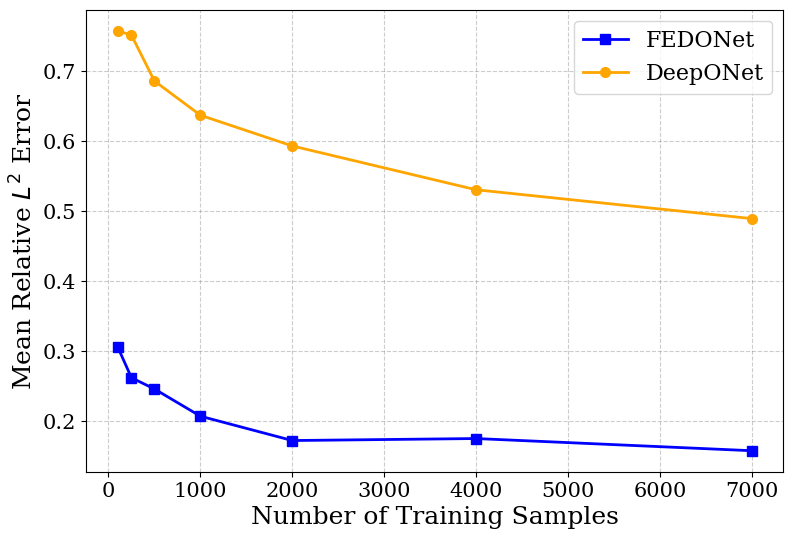

In [4]:
import matplotlib as mpl

def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 6))

plt.figure(figsize=(9, 6))
plt.plot(n_vals, fedo_vals, marker='s', color = 'blue',label='FEDONet')
plt.plot(n_vals, deep_vals, marker='o', color = 'orange', label='DeepONet')
# plt.yscale('log')
plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Relative $L^2$ Error')
# plt.title('Effect of Training Set Size on Test Relative $L_2$ Error')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

In [5]:
fedo_vals

[np.float64(0.3063111234009266),
 np.float64(0.26228849313408137),
 np.float64(0.2462840689010918),
 np.float64(0.20746922758221625),
 np.float64(0.1727336416132748),
 np.float64(0.17557920330762863),
 np.float64(0.1582034209817648)]

In [6]:
deep_vals

[np.float64(0.757370198532939),
 np.float64(0.7510349287986755),
 np.float64(0.6856134230941534),
 np.float64(0.6368237216919661),
 np.float64(0.5930001204162836),
 np.float64(0.5304791300296784),
 np.float64(0.4893347108364105)]

Sample index          : 0
FEDONet Rel L2 Error  : 9.537548e-02
DeepONet Rel L2 Error : 4.964645e-01


C:\Users\asojitra\AppData\Local\Temp\ipykernel_33404\2885395301.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


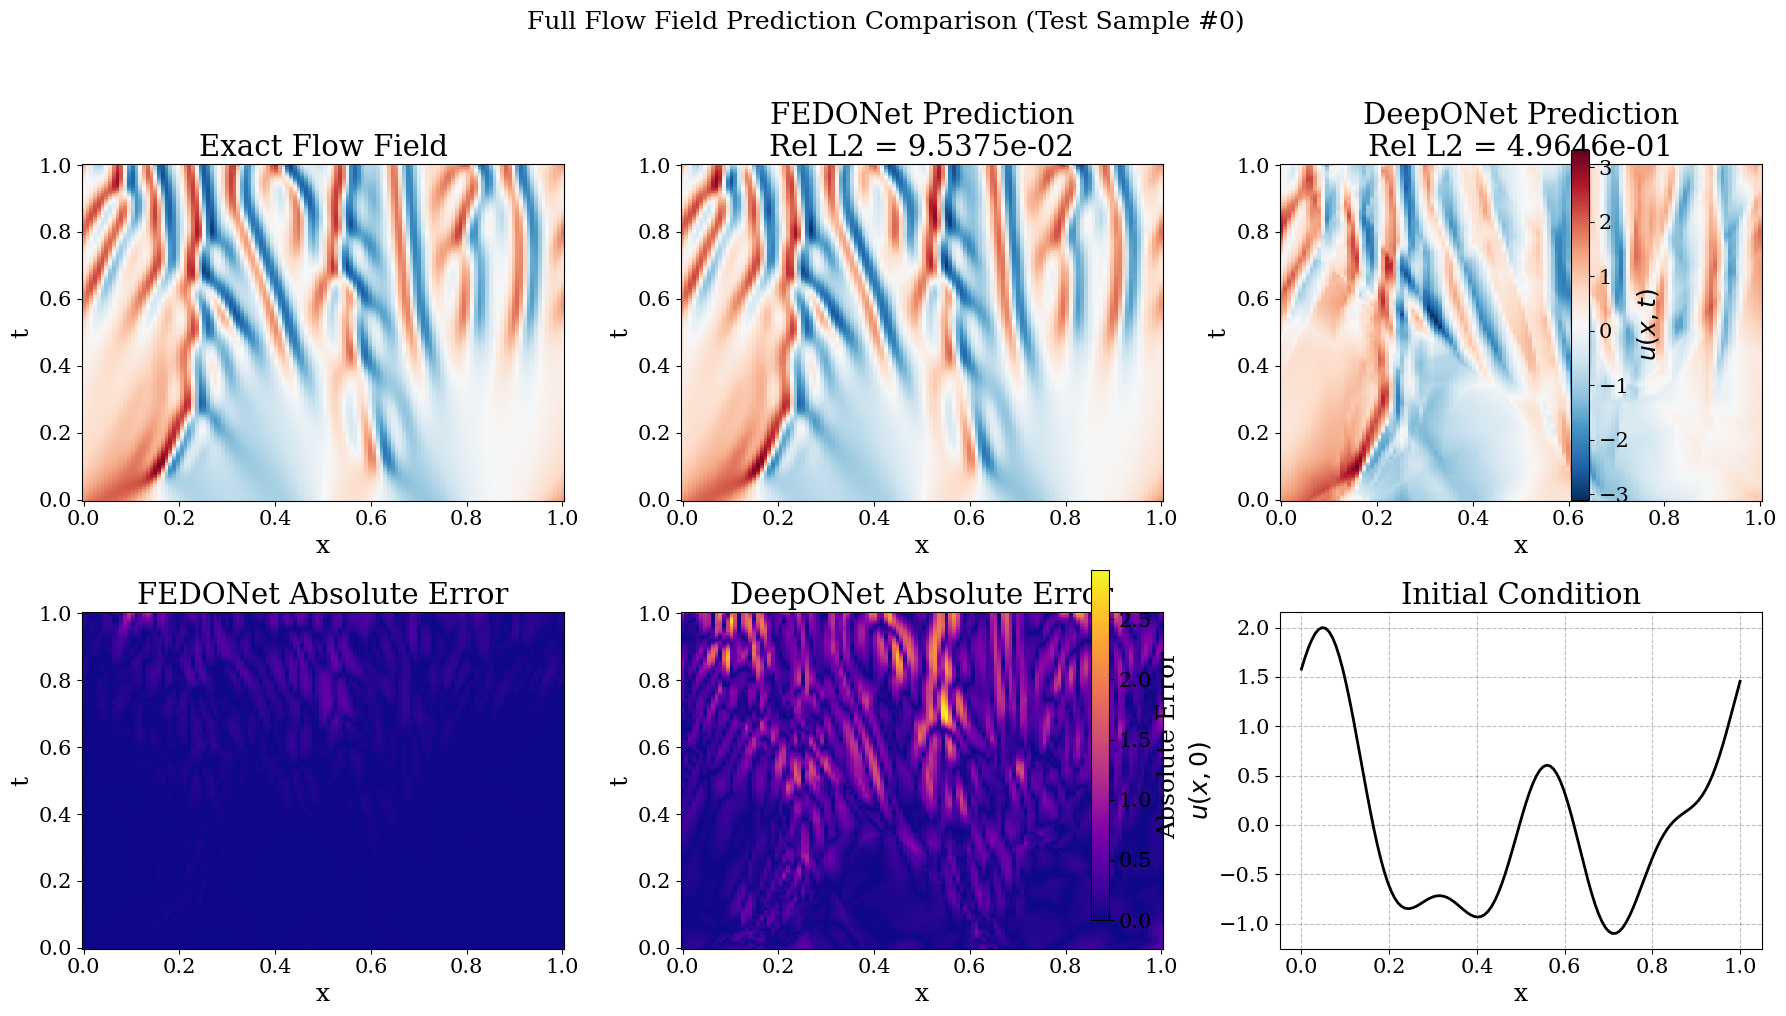

In [9]:
# ============================================================
# FINAL VISUALIZATION BLOCK: FULL FLOW FIELD COMPARISON
# Run this AFTER training is complete
# Assumes:
#   model         -> FEDONet
#   model_normal  -> DeepONet
#   X_test, y_test, coords, device, x, t already exist
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Choose a test sample index
# -----------------------------
viz_idx = 0   # change to any test sample index you want

# -----------------------------
# Make sure coords is a torch tensor on device
# -----------------------------
if isinstance(coords, np.ndarray):
    coords_torch = torch.tensor(coords, dtype=torch.float32).to(device)
else:
    coords_torch = coords.to(device)

# -----------------------------
# Extract one test sample
# -----------------------------
ic_sample = X_test[viz_idx]     # expected shape: [128]
y_true_sample = y_test[viz_idx] # expected shape: [224, 128] or [128, 224]

# If y_true is [128, 224], transpose to [224, 128]
if y_true_sample.shape == (128, 224):
    y_true_sample = y_true_sample.T

# -----------------------------
# Predict with both models
# -----------------------------
ic_tensor = torch.tensor(ic_sample, dtype=torch.float32).unsqueeze(0).to(device)

deeponet.eval()
fedonet.eval()

with torch.no_grad():
    y_pred_fedo = fedonet(ic_tensor, coords_torch).squeeze(0).cpu().numpy()
    y_pred_deep = deeponet(ic_tensor, coords_torch).squeeze(0).cpu().numpy()

# Safety shape fix if needed
if y_pred_fedo.shape == (128, 224):
    y_pred_fedo = y_pred_fedo.T
if y_pred_deep.shape == (128, 224):
    y_pred_deep = y_pred_deep.T

# -----------------------------
# Error fields
# -----------------------------
err_fedo = np.abs(y_true_sample - y_pred_fedo)
err_deep = np.abs(y_true_sample - y_pred_deep)

# -----------------------------
# Relative L2 errors for this sample
# -----------------------------
rel_l2_fedo = np.linalg.norm(y_true_sample - y_pred_fedo) / (np.linalg.norm(y_true_sample) + 1e-12)
rel_l2_deep = np.linalg.norm(y_true_sample - y_pred_deep) / (np.linalg.norm(y_true_sample) + 1e-12)

print(f"Sample index          : {viz_idx}")
print(f"FEDONet Rel L2 Error  : {rel_l2_fedo:.6e}")
print(f"DeepONet Rel L2 Error : {rel_l2_deep:.6e}")

# -----------------------------
# Common color scales
# -----------------------------
field_vmin = min(y_true_sample.min(), y_pred_fedo.min(), y_pred_deep.min())
field_vmax = max(y_true_sample.max(), y_pred_fedo.max(), y_pred_deep.max())

err_vmin = 0.0
err_vmax = max(err_fedo.max(), err_deep.max())

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Exact
im0 = axes[0, 0].pcolormesh(x, t, y_true_sample, shading='auto',
                            cmap='RdBu_r', vmin=field_vmin, vmax=field_vmax)
axes[0, 0].set_title('Exact Flow Field')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('t')

# FEDONet
im1 = axes[0, 1].pcolormesh(x, t, y_pred_fedo, shading='auto',
                            cmap='RdBu_r', vmin=field_vmin, vmax=field_vmax)
axes[0, 1].set_title(f'FEDONet Prediction\nRel L2 = {rel_l2_fedo:.4e}')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('t')

# DeepONet
im2 = axes[0, 2].pcolormesh(x, t, y_pred_deep, shading='auto',
                            cmap='RdBu_r', vmin=field_vmin, vmax=field_vmax)
axes[0, 2].set_title(f'DeepONet Prediction\nRel L2 = {rel_l2_deep:.4e}')
axes[0, 2].set_xlabel('x')
axes[0, 2].set_ylabel('t')

# FEDONet error
im3 = axes[1, 0].pcolormesh(x, t, err_fedo, shading='auto',
                            cmap='plasma', vmin=err_vmin, vmax=err_vmax)
axes[1, 0].set_title('FEDONet Absolute Error')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('t')

# DeepONet error
im4 = axes[1, 1].pcolormesh(x, t, err_deep, shading='auto',
                            cmap='plasma', vmin=err_vmin, vmax=err_vmax)
axes[1, 1].set_title('DeepONet Absolute Error')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('t')

# Initial condition
axes[1, 2].plot(x, ic_sample, linewidth=2, color='k')
axes[1, 2].set_title('Initial Condition')
axes[1, 2].set_xlabel('x')
axes[1, 2].set_ylabel(r'$u(x,0)$')
axes[1, 2].grid(True)

# Colorbars
cbar1 = fig.colorbar(im0, ax=axes[0, :], fraction=0.025, pad=0.04)
cbar1.set_label(r'$u(x,t)$')

cbar2 = fig.colorbar(im3, ax=axes[1, 0:2], fraction=0.025, pad=0.04)
cbar2.set_label('Absolute Error')

plt.suptitle(f'Full Flow Field Prediction Comparison (Test Sample #{viz_idx})', y=1.02, fontsize=18)
plt.tight_layout()
plt.show()